## Correlation distance clustering

In [1]:
import numpy as np

DATA_PATH = "student_mental_health_burnout_1M.csv"

# loading dataset
import pandas as pd
df_1m = pd.read_csv(DATA_PATH)

# extract numerical features
from pandas.api.types import is_numeric_dtype
numeric_cols = [col for col in df_1m.columns if is_numeric_dtype(df_1m[col])]
num_df_1m = df_1m[numeric_cols].copy()

num_df_1m.iloc[1:100]

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,0.000000
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,0.696941
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,5.380592
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,0.000000
5,29,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,2.731063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29,3,5.375062,5.338316,80.982024,5.759744,4.271680,3.533563,7.312874,2.980812,3.908400,7.057710,8.622998,9.713833,5.988744,2.950994,5.354529,4.174980
96,18,3,7.958061,9.502525,75.987530,6.433656,3.728825,1.373351,8.517508,2.637354,6.348850,5.133156,4.177367,5.851558,8.886635,2.670052,5.895885,3.365640
97,21,4,8.706658,7.597969,77.639096,7.092993,5.946303,3.397777,5.425566,2.366063,4.963052,4.937139,6.214089,5.486136,8.515191,3.597517,4.359579,1.732625
98,24,4,6.371529,5.788810,71.993119,4.895763,4.286411,1.329208,4.521030,3.077423,6.007947,4.227321,4.804397,3.157183,9.168905,2.384478,6.357009,0.020018


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# standardize data
preproc_cluster = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
#    ("scale", StandardScaler())    # don't apply data scaling for correlation distance
])

# limit the dataframe size to make the computation feasible
SAMPLE_SIZE = 10_000
idx = np.random.default_rng(1234).choice(len(num_df_1m), size=SAMPLE_SIZE, replace=False)
num_df_reduced = num_df_1m.iloc[idx].copy()

std_num_df = pd.DataFrame(preproc_cluster.fit_transform(num_df_reduced), columns=num_df_reduced.columns)

In [19]:
# get the correlation distance
from scipy.spatial.distance import pdist, squareform
corr_dist_mat = squareform(pdist(std_num_df, metric="correlation"))

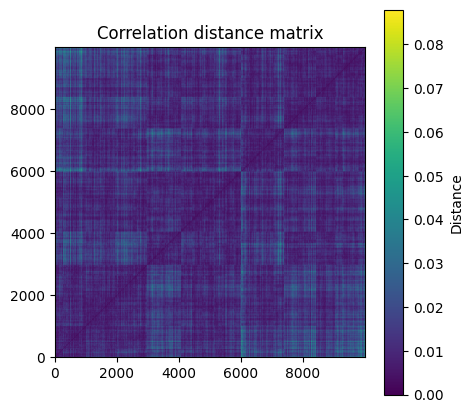

In [20]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# order datapoints based on their correlation distance
order = leaves_list(linkage(squareform(corr_dist_mat, checks=False), method="ward"))
ordered = corr_dist_mat[np.ix_(order, order)]

fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(ordered, aspect="equal", origin="lower")
plt.title("Correlation distance matrix")
plt.colorbar(im, label="Distance")
plt.show()

## DBSCAN

In [9]:
MIN_NEIGHBORS_TO_TEST  = 30
min_neigh_range = [i for i in range(2,MIN_NEIGHBORS_TO_TEST+1)]

from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# dicts for later plotting
k_dists = dict()   
knee_points = dict()
eps_vals = dict()
corr_dist_mat = squareform(pdist(std_num_df, metric="correlation"))

def get_best_eps(min_neigh :int, corr_mat) ->float:
    """
    Automatically find the best eps values (knee of the k-distance plot) for min_neigh value
    """
    # 1st: compute the k-distance
    nbrs = NearestNeighbors(n_neighbors=min_neigh, metric="precomputed")
    nbrs.fit(corr_mat)
    dist, _ = nbrs.kneighbors(corr_mat)   
    k_dist = np.sort(dist[:,-1])

    k_dists[min_neigh] = k_dist # store for plotting
    # 2nd: highlight the knee
    kneedle = KneeLocator(range(len(k_dist)), k_dist, 
                      curve='convex', direction='increasing')
    knee_points[min_neigh] = kneedle.knee
    return float(k_dist[kneedle.knee])

from sklearn.cluster import DBSCAN
print("----- starting DBSCAN trend clustering -----")
clusterings_labels = dict()
for min_neigh in min_neigh_range:
    print(f">> computing DBSCAN on min_samples={min_neigh}")
    eps = get_best_eps(min_neigh, corr_dist_mat)
    eps_vals[min_neigh] = eps   # store for plotting
    print(f"   eps value found {eps}")
    dbscan = DBSCAN(eps=eps, min_samples=min_neigh, metric="precomputed")
    clusterings_labels[min_neigh] = dbscan.fit_predict(corr_dist_mat)

----- starting DBSCAN trend clustering -----
>> computing DBSCAN on min_samples=2
   eps value found 0.0033586056142475007
>> computing DBSCAN on min_samples=3
   eps value found 0.003123265122730756
>> computing DBSCAN on min_samples=4
   eps value found 0.0035451959201787675
>> computing DBSCAN on min_samples=5
   eps value found 0.003819445803863508
>> computing DBSCAN on min_samples=6
   eps value found 0.003674036940776615
>> computing DBSCAN on min_samples=7
   eps value found 0.0036870691582098214
>> computing DBSCAN on min_samples=8
   eps value found 0.004513565762013783
>> computing DBSCAN on min_samples=9
   eps value found 0.003798905319360002
>> computing DBSCAN on min_samples=10
   eps value found 0.004220537212200837
>> computing DBSCAN on min_samples=11
   eps value found 0.0039985757460735405
>> computing DBSCAN on min_samples=12
   eps value found 0.005084851639474142
>> computing DBSCAN on min_samples=13
   eps value found 0.004487226114469722
>> computing DBSCAN on 

In [11]:
for min_neigh in min_neigh_range:
    print(f"Cluster identified with min_pts={min_neigh}-eps={eps_vals[min_neigh]:.4f}:{len(set(clusterings_labels[min_neigh]))\
                                                                                        - (1 if -1 in clusterings_labels[min_neigh] else 0)}")

Cluster identified with min_pts=2-eps=0.0034:2
Cluster identified with min_pts=3-eps=0.0031:1
Cluster identified with min_pts=4-eps=0.0035:1
Cluster identified with min_pts=5-eps=0.0038:1
Cluster identified with min_pts=6-eps=0.0037:1
Cluster identified with min_pts=7-eps=0.0037:1
Cluster identified with min_pts=8-eps=0.0045:1
Cluster identified with min_pts=9-eps=0.0038:1
Cluster identified with min_pts=10-eps=0.0042:1
Cluster identified with min_pts=11-eps=0.0040:1
Cluster identified with min_pts=12-eps=0.0051:1
Cluster identified with min_pts=13-eps=0.0045:1
Cluster identified with min_pts=14-eps=0.0044:1
Cluster identified with min_pts=15-eps=0.0042:1
Cluster identified with min_pts=16-eps=0.0043:1
Cluster identified with min_pts=17-eps=0.0044:1
Cluster identified with min_pts=18-eps=0.0045:1
Cluster identified with min_pts=19-eps=0.0048:1
Cluster identified with min_pts=20-eps=0.0050:1
Cluster identified with min_pts=21-eps=0.0050:1
Cluster identified with min_pts=22-eps=0.0053:1


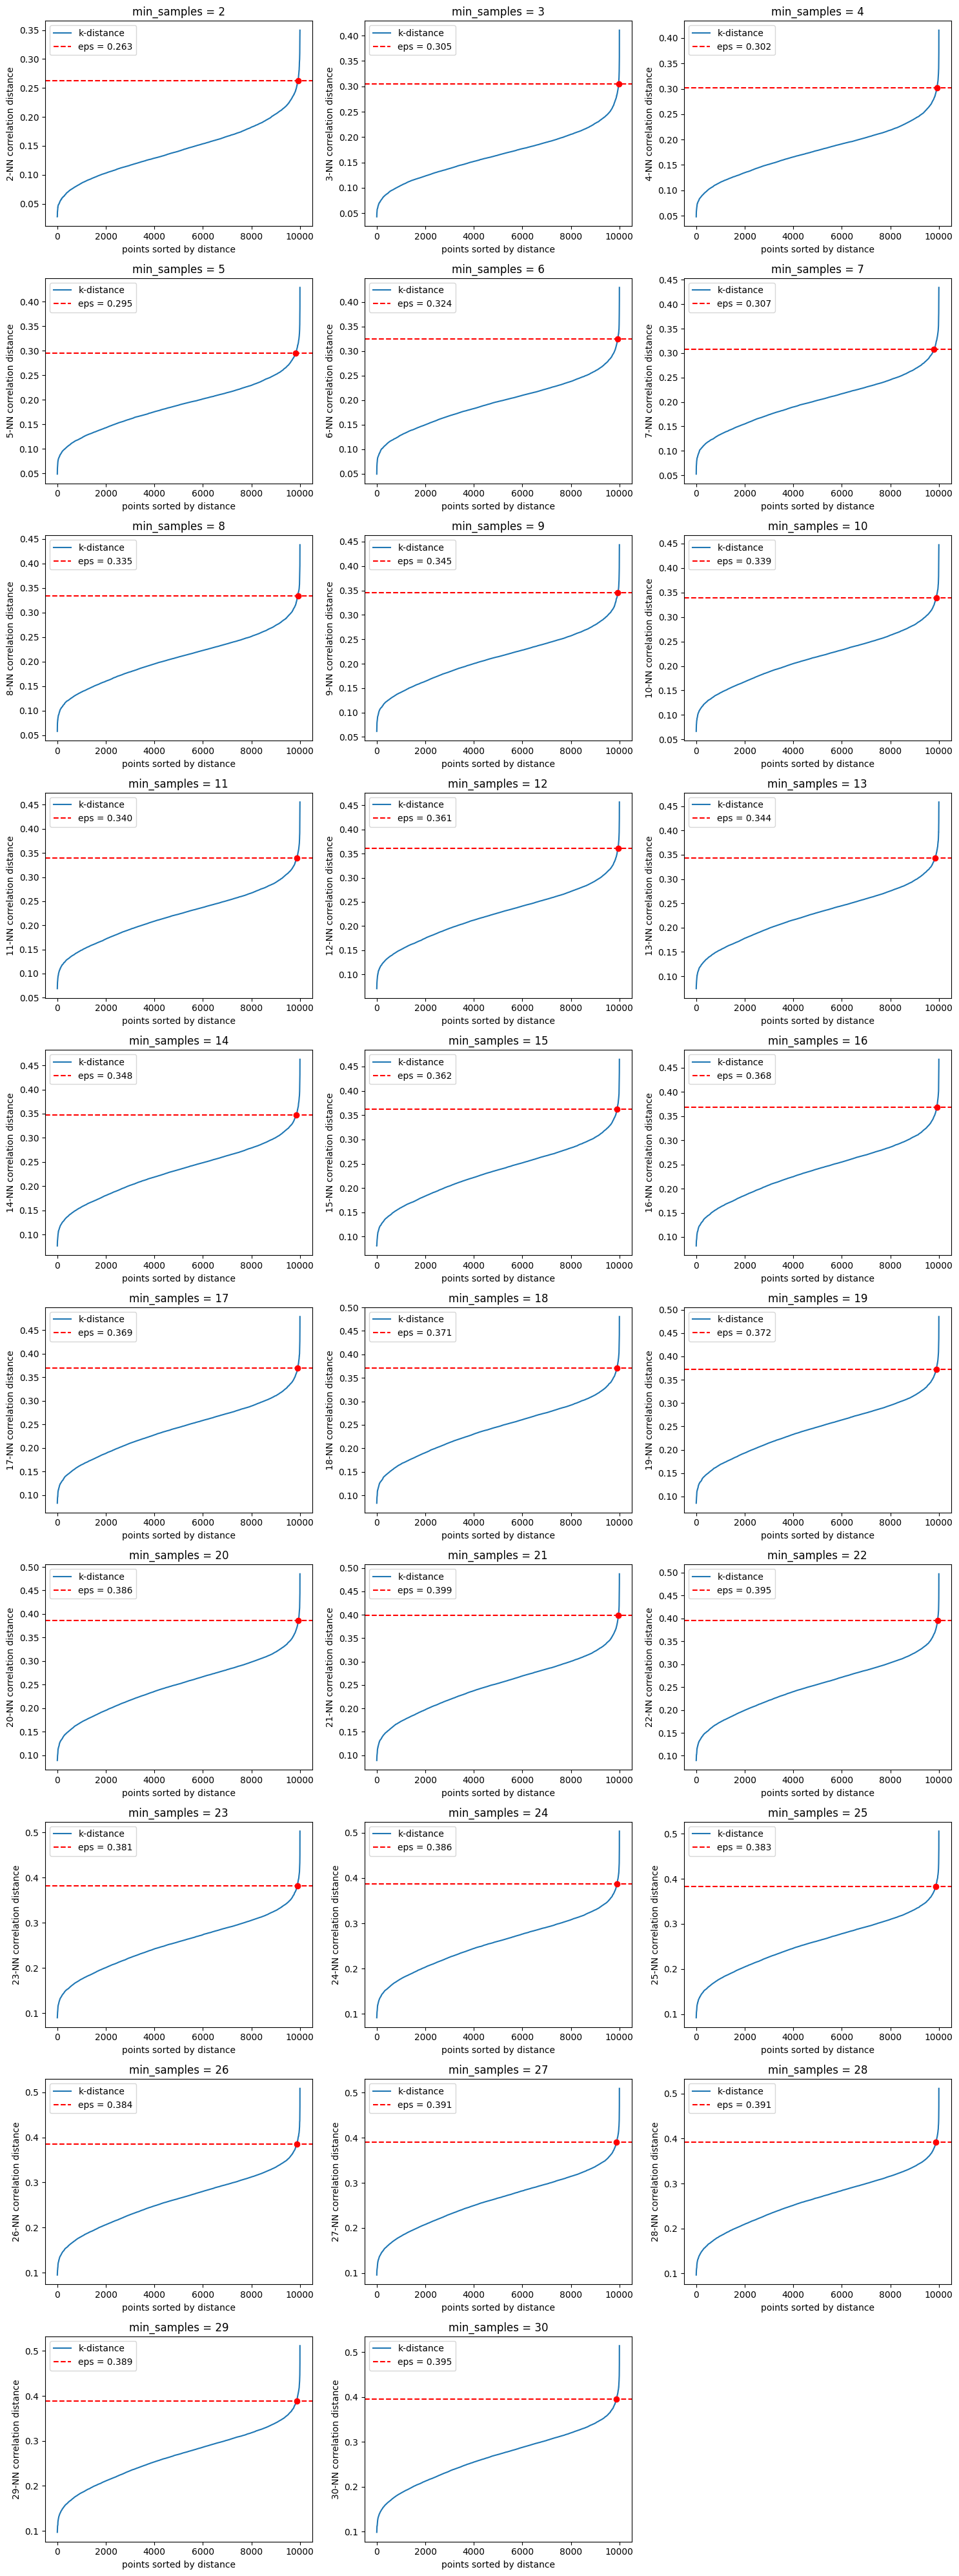

In [7]:
n_cols = 3
n_rows = int(np.ceil(len(min_neigh_range) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, min_neigh in zip(axes, min_neigh_range):
    k_dist = k_dists[min_neigh]
    knee = knee_points[min_neigh]
    eps = eps_vals[min_neigh]

    ax.plot(k_dist, label="k-distance")
    ax.axhline(eps, color="r", linestyle="--", label=f"eps = {eps:.3f}")
    ax.scatter([knee], [eps], color="r", zorder=5)
    ax.set_title(f"min_samples = {min_neigh}")
    ax.set_xlabel("points sorted by distance")
    ax.set_ylabel(f"{min_neigh}-NN correlation distance")
    ax.legend()

for ax in axes[len(min_neigh_range):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Spectral Clustering


In [21]:
# building the graph by similarity
sigma = np.median(corr_dist_mat)
print(f"sigma value: {sigma}")
affinity_mat = np.exp(-corr_dist_mat**2 / (2 * sigma**2))

sigma value: 0.011067379155803414


Text(0.5, 1.0, 'Weighted degree distribution')

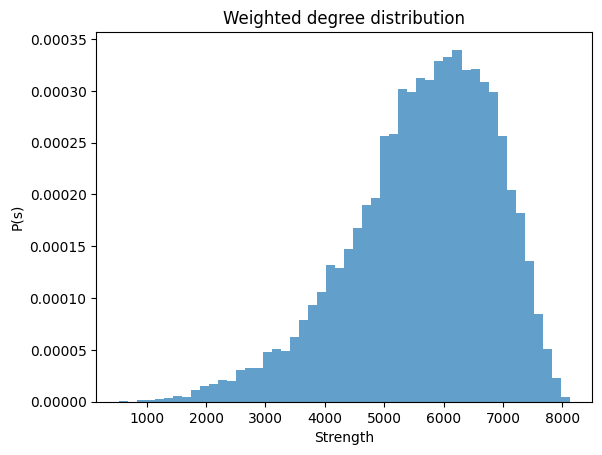

In [51]:
strength = affinity_mat.sum(axis=1)  # weighted degree for each node

plt.hist(strength, bins=50, density=True, alpha=0.7, label='node strength')
plt.xlabel('Strength')
plt.ylabel('P(s)')
plt.title('Weighted degree distribution')

In [22]:
from scipy.sparse.csgraph import laplacian

# affinity matrix Laplacian
L = laplacian(affinity_mat, normed=True)
eigenvalues = np.linalg.eigvalsh(L)

In [ ]:
from scipy.sparse.csgraph import laplacian

# building random graph for comparison
null_mat = affinity_mat.copy()
# if the two matrices doesn't fit in memory, for the mixed features run this
# null_mat = affinity_mat_mixed.copy()
np.random.shuffle(null_mat)
L_null = laplacian(null_mat, normed=True)
eigvals_null = np.linalg.eigvalsh(L_null)

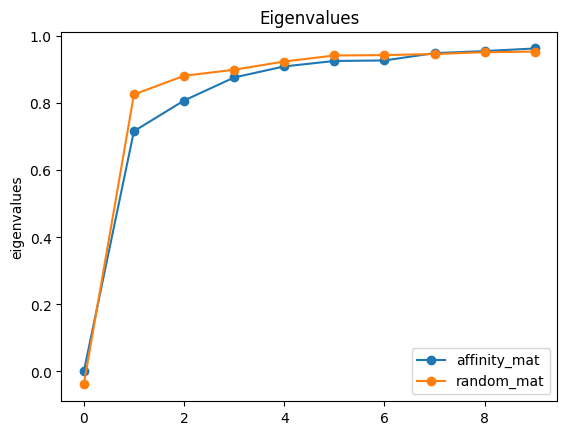

In [53]:
plt.plot(eigenvalues[:10], 'o-', label="affinity_mat")
plt.plot(eigvals_null[:10], 'o-', label="random_mat")
plt.ylabel("eigenvalues")
plt.title("Eigenvalues")
plt.legend()
plt.show()

In [23]:
from sklearn.cluster import SpectralClustering

# Spectral Clustering (SC) works using eigenvalues of the Laplacian matrix of the data.
# More info: https://grahamjroy.medium.com/spectral-clustering-when-clusters-dont-look-like-blobs-a205e1fc8d0e

sc = SpectralClustering(
    n_clusters=2,
    affinity="precomputed", 
    assign_labels="kmeans",   # more or less same result using "discretize"
    random_state=42,
    n_init=10                 # run kmeans multiple times for stability
)
labels = sc.fit_predict(affinity_mat)

print(np.unique(labels, return_counts=True))

(array([0, 1], dtype=int32), array([5430, 4570]))


In [24]:
from sklearn.metrics import silhouette_score

sil_overall = silhouette_score(affinity_mat, labels)
print(f"silhouette score for mixed features: {sil_overall}")

silhouette score for mixed features: 0.24376215507352644


## Spectral clustering on PCA + original features

trying out spectral clustering with correlation distance on the mixed set of features.

In [3]:
from sklearn.decomposition import PCA

# numeber of components taken from the pca_modified.ipynb
NUM_PCA = 10
pca_feats = [f"PCA{i+1}" for i in range(NUM_PCA)]
pca = PCA(n_components=NUM_PCA, random_state=42)
df_pca = pd.DataFrame(pca.fit_transform(std_num_df), columns=pca_feats)

selected_original_feats = ["academic_performance", "financial_stress", "family_expectation", "physical_activity", "sleep_hours", "academic_year", "age"]
mixed_df = pd.concat([df_pca, std_num_df[selected_original_feats]], axis=1)

mixed_df

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,academic_performance,financial_stress,family_expectation,physical_activity,sleep_hours,academic_year,age
0,2.723901,-5.025144,1.324765,-0.224875,2.027240,3.425494,0.083901,2.374869,0.949285,-0.264545,73.411284,6.352411,7.447066,4.591437,7.766536,2.0,18.0
1,0.472924,-1.954323,1.346526,0.464469,-5.457321,-1.237308,-2.811110,-2.937107,2.004958,0.315247,72.051611,7.862062,4.115215,3.671098,3.521542,3.0,21.0
2,6.646883,-5.079777,-2.917097,-1.542680,-2.120440,5.911709,-2.136737,0.848420,1.697458,1.796162,78.282348,7.587023,5.369514,5.189937,7.736741,4.0,18.0
3,0.470822,-3.080227,-4.852601,1.021389,-1.613474,-2.808565,1.718185,0.060608,0.954203,-0.808633,72.040124,2.831302,6.362903,4.058493,6.308515,2.0,20.0
4,4.666369,-3.928012,1.304409,-2.255634,-1.622927,-0.598834,2.544737,1.543617,1.254749,0.337830,75.593717,5.087716,9.026756,4.383040,6.717051,3.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4.159272,-1.018267,1.400297,-0.239965,1.556229,5.143026,-2.803855,0.853549,0.698496,-0.324554,74.897253,8.083729,5.013234,3.922808,6.513456,2.0,22.0
9996,-4.068479,4.866917,-3.234559,4.506267,-1.237630,0.274619,4.713978,-0.655177,-1.049581,-0.608181,67.574421,2.028206,9.550394,1.628886,6.232633,2.0,28.0
9997,4.110609,-2.873515,3.221161,-2.175171,-1.994571,0.538556,0.163524,-0.167941,-2.875441,-0.290246,75.037367,6.356771,7.149890,0.000000,7.469037,2.0,20.0
9998,-10.305027,-0.002009,3.040449,0.049730,1.980480,-0.794373,-0.818400,-0.378861,-0.741750,0.556566,60.353714,5.008986,5.250216,2.082088,6.319487,3.0,23.0


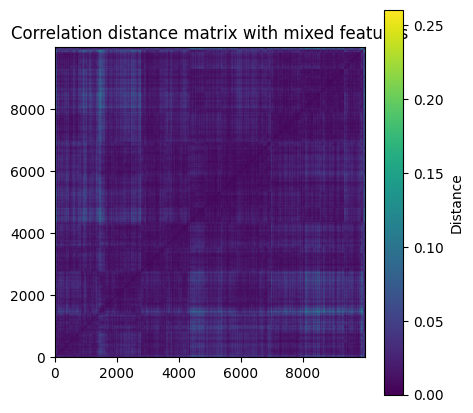

In [6]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform

corr_dist_mixed = squareform(pdist(mixed_df, metric="correlation"))

order = leaves_list(linkage(squareform(corr_dist_mixed, checks=False), method="average"))
ordered = corr_dist_mixed[np.ix_(order, order)]

fig, ax = plt.subplots(1, 1, figsize=(5,5))
im = ax.imshow(ordered, aspect="equal", origin="lower")
plt.title("Correlation distance matrix with mixed features")
plt.colorbar(im, label="Distance")
plt.show()

In [7]:
sigma_mixed = np.median(corr_dist_mixed) 
affinity_mat_mixed = np.exp(-corr_dist_mixed**2 / (2 * sigma_mixed**2))

Text(0.5, 1.0, 'Weighted degree distribution for mixed PCA+original features')

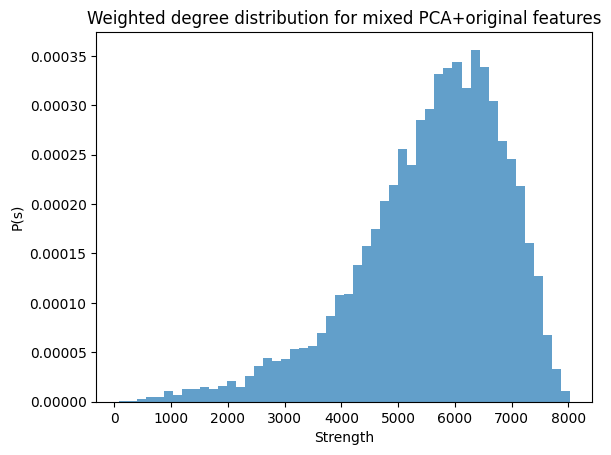

In [8]:
strength_mixed = affinity_mat_mixed.sum(axis=1)  # weighted degree for each node

plt.hist(strength_mixed, bins=50, density=True, alpha=0.7, label='node strength')
plt.xlabel('Strength')
plt.ylabel('P(s)')
plt.title('Weighted degree distribution for mixed PCA+original features')

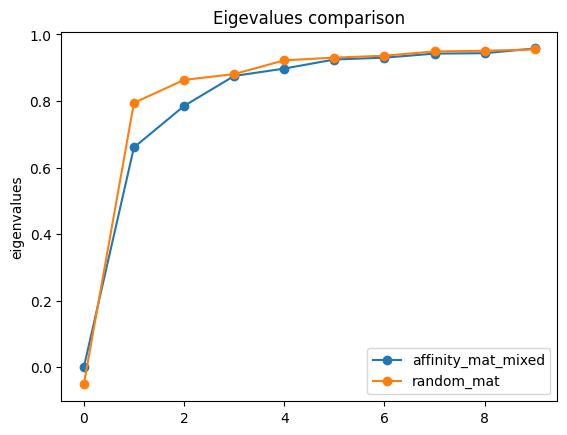

In [13]:
from scipy.sparse.csgraph import laplacian

L_mixed = laplacian(affinity_mat_mixed, normed=True)
eigenvals_mixed = np.linalg.eigvalsh(L_mixed)

plt.plot(eigenvals_mixed[:10], 'o-', label="affinity_mat_mixed")
plt.plot(eigvals_null[:10], 'o-', label="random_mat")
plt.ylabel("eigenvalues")
plt.title("Eigevalues comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(
    n_clusters=2,
    affinity="precomputed", 
    assign_labels="kmeans",
    random_state=42,
    n_init=10
)
labels_mixed = sc.fit_predict(affinity_mat_mixed)

print(np.unique(labels_mixed, return_counts=True))

(array([0, 1], dtype=int32), array([6958, 3042]))


In [18]:
from sklearn.metrics import silhouette_score

sil_overall_mixed = silhouette_score(affinity_mat_mixed, labels_mixed)
print(f"silhouette score for mixed features: {sil_overall_mixed}")

silhouette score for mixed features: 0.2915157671512902
